In [18]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
import os
os.getcwd()
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
base_path = "/content/drive/MyDrive/Clg_Project/"

meals_info_path = base_path+'meal_info.csv'
sales_path = '../data/raw/data.csv'
centre_info = base_path+'fulfilment_center_info.csv'

In [6]:
import os
os.getcwd()

'/Users/prince-khatri/Documents/Learning/Meals_prediction_model/notebooks'

In [8]:
# meals_df = pd.read_csv(meals_info_path)
train_df = pd.read_csv(sales_path)
# centre_df = pd.read_csv(centre_info)

In [ ]:
# meals_df.head()
# meals_df.nunique()

In [9]:
train_df.nunique()

id                       456548
week                        145
center_id                    77
meal_id                      51
checkout_price             1992
base_price                 1907
emailer_for_promotion         2
homepage_featured             2
num_orders                 1250
dtype: int64

/var/folders/_r/_zh67rmx3t9g6lrcny8nn72h0000gn/T/ipykernel_9725/2755339415.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


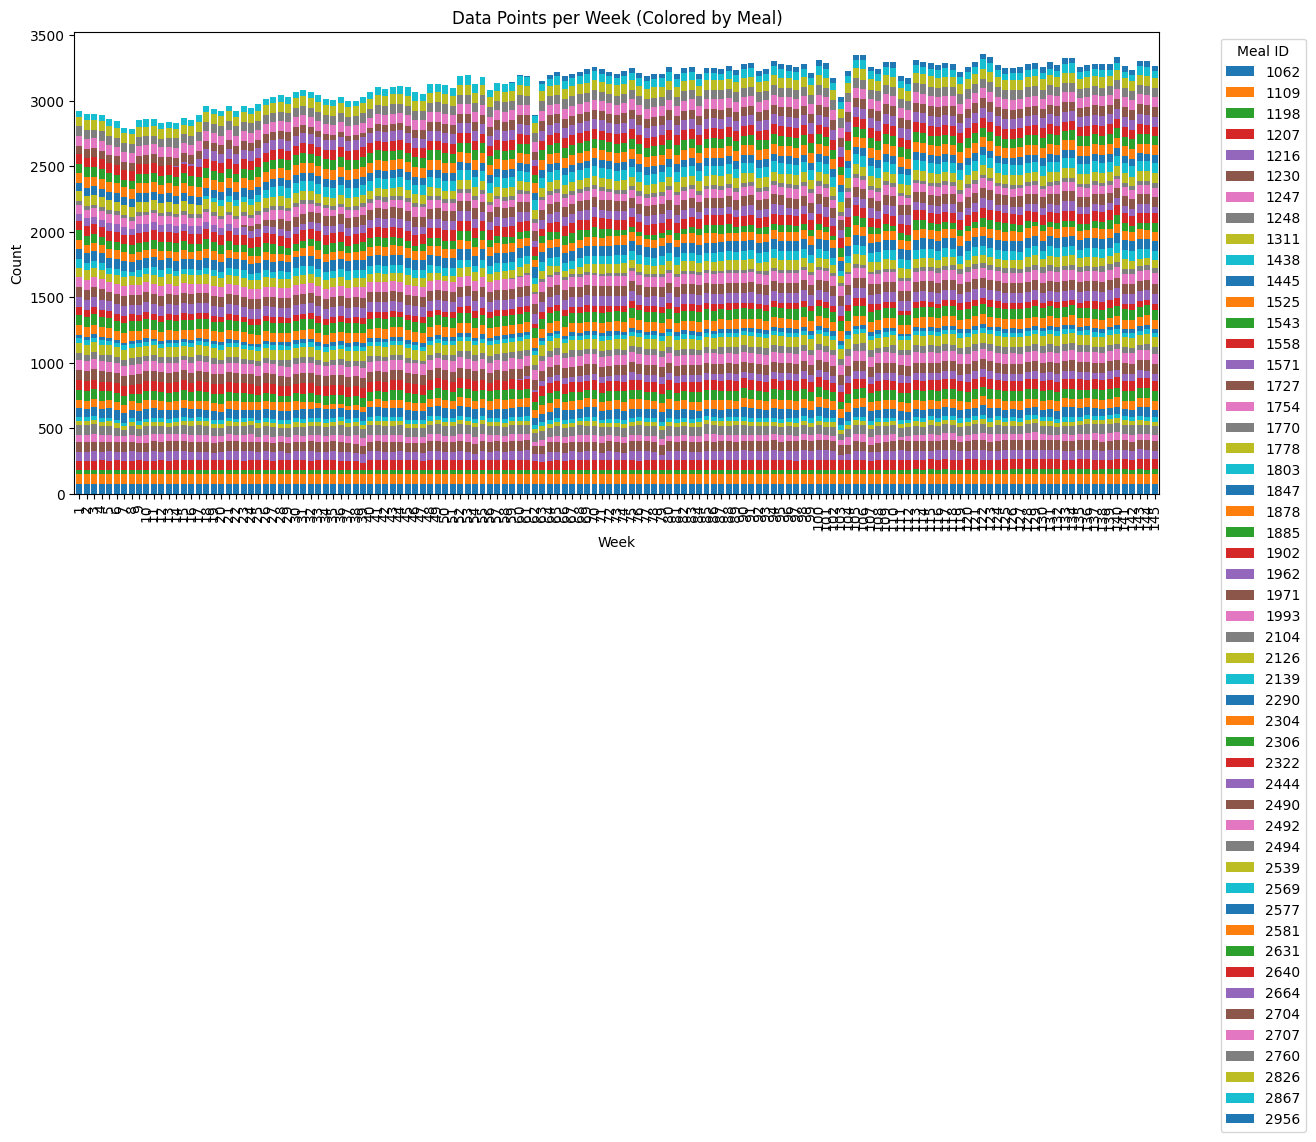

In [19]:
import matplotlib.pyplot as plt

# Count per week per meal
week_meal_counts = train_df.groupby(['week', 'meal_id']).size().unstack(fill_value=0)

# Plot stacked bar
week_meal_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6),
    width=0.8
)

plt.title("Data Points per Week (Colored by Meal)")
plt.xlabel("Week")
plt.ylabel("Count")
plt.legend(title="Meal ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# centre_df.nunique()

In [ ]:
# from sklearn.preprocessing import LabelEncoder
# for col in train_df.select_dtypes(include='object').columns:
#     train_df[col] = LabelEncoder().fit_transform(train_df[col])

In [10]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB


In [11]:

!pip install lightgbm xgboost catboost


from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import matplotlib.pyplot as plt
%inline

In [ ]:

def features(df):
    df = df.sort_values(['meal_id','center_id','week'])

    # Lag features
    df['lag_1'] = df.groupby(['meal_id','center_id'])['num_orders'].shift(1)
    df['lag_2'] = df.groupby(['meal_id','center_id'])['num_orders'].shift(2)
    df['lag_3'] = df.groupby(['meal_id','center_id'])['num_orders'].shift(3)
    df['lag_4'] = df.groupby(['meal_id','center_id'])['num_orders'].shift(4)

    df['rolling_mean_3'] = df.groupby(['meal_id','center_id'])['num_orders']\
                            .shift(1).rolling(3).mean()

    df['rolling_mean_5'] = df.groupby(['meal_id','center_id'])['num_orders']\
                            .shift(1).rolling(5).mean()

    df['trend'] = df['lag_1'] - df['lag_2']
    df['growth'] = df['lag_1'] / (df['lag_2'] + 1)

    return df

In [12]:
models = [LGBMRegressor(), XGBRegressor(), CatBoostRegressor()]
models = [LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)]

In [13]:
train = train_df[train_df['week'] < 130]
test = train_df[train_df['week'] >= 130]

X_train = train.drop(columns=['num_orders'])
y_train = train['num_orders']
X_test = test.drop(columns=['num_orders'])
y_test = test['num_orders']

y_train_cpy = y_train.copy()
y_test_cpy = y_test.copy()

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)


In [15]:
import numpy as np
from sklearn.metrics import r2_score
def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))




def find_metrics(y_true, y_pred):
    wmape_np = wmape(y_true, y_pred)
    rmsle_np = rmsle(y_true, y_pred)
    mae_np = mae(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return wmape_np, rmsle_np, mae_np, r2



In [16]:
train_metrics=[]
test_metrics = []
model_name = ['lgb', 'xgb', 'cat']
hpt_grid = [{
        'n_estimators': [500, 1000, 2000],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 63, 127],          # Crucial for complexity
        'max_depth': [10, 15, 20],        # -1 allows unlimited depth
        'min_child_samples': [20, 50, 70],
        'feature_fraction': [0.6, 0.8, 1.0],
        'lambda_l1': [0, 0.1, .2],           # L1 Regularization
        'lambda_l2': [0, 0.1, .2]            # L2 Regularization
    },
    {
        'n_estimators': [500, 1000, 1500],
        'max_depth': [3, 5, 7, 9],            # Shallow trees generalize better
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 5, 10],       # Higher = more conservative
        'gamma': [0, 0.1, 0.5],               # Minimum loss reduction for split
        'reg_alpha': [0, 0.1, 1.0],
        'reg_lambda': [1.0, 5.0, 10.0]
    },
    {
        'iterations': [500, 1000],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [4, 6, 8, 10],
        'l2_leaf_reg': [1, 3, 5, 9],
        'random_strength': [1, 5, 10],
        'bagging_temperature': [0, 0.5, 1],
        'border_count': [128, 254]            # Discretization of numerical features
    }
]


In [17]:

from sklearn.model_selection import RandomizedSearchCV

for i,model in enumerate(models):
    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=hpt_grid[i],
        n_iter=5,                # Number of parameter settings sampled
        cv=3,
        scoring='neg_mean_absolute_error',
        verbose=2,
        random_state=42,
        n_jobs=-1
    )

    rs.fit(X_train, y_train)
    train_pred = rs.predict(X_train)
    test_pred = rs.predict(X_test)

    train_metrics.append(find_metrics(y_train, train_pred))
    test_metrics.append(find_metrics(y_test, test_pred))


Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.8 will b

KeyboardInterrupt: 

In [ ]:
y_pred_train = np.expm1(rs.predict(X_train))
y_pred_test = np.expm1(rs.predict(X_test))

train_metrics[0] = find_metrics(y_train_cpy, y_pred_train)
test_metrics[0] = find_metrics(y_test_cpy, y_pred_test)

In [ ]:
train_df.num_orders.describe()

In [ ]:
for i in range(1):
    print(model_name[i])
    print(train_metrics[i])
    print(test_metrics[i])

In [ ]:
import dill

with open(base_path+"model2.pkl", "wb") as f:
    dill.dump(models[0], f)


In [ ]:
def plot_predictions(y_true_train, y_pred_train, y_true_test, y_pred_test):

    # Create index for x-axis
    train_idx = np.arange(len(y_true_train))
    test_idx = np.arange(len(y_true_train), len(y_true_train) + len(y_true_test))

    # Absolute errors
    train_error = np.abs(y_true_train - y_pred_train)
    test_error = np.abs(y_true_test - y_pred_test)

    plt.figure(figsize=(14, 8))

    # ---- Plot TRUE vs PRED ----
    plt.subplot(2, 1, 1)

    plt.plot(train_idx, y_true_train, label="Train True")
    plt.plot(train_idx, y_pred_train, linestyle='--', label="Train Pred")

    plt.plot(test_idx, y_true_test, label="Test True")
    plt.plot(test_idx, y_pred_test, linestyle='--', label="Test Pred")

    plt.title("True vs Predicted (Train + Test)")
    plt.legend()

    # ---- Plot ABSOLUTE ERROR ----
    plt.subplot(2, 1, 2)

    plt.plot(train_idx, train_error, label="Train Abs Error")
    plt.plot(test_idx, test_error, label="Test Abs Error")

    plt.title("Absolute Error")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
plot_predictions()

NameError: name 'plot_predictions' is not defined